In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## What is sampling?
Sampling is a statistical method that allows us to infer information about a population based on the statistics from a subset of the population (a sample), without having to measure every individual in the population. 

In the real world, sampling is used in many fields, including polling. For example, pollsters don't ask every eligible voter who they're voting for. Instead, they ask a small, randomly selected sample of voters, and use the results to estimate the preferences of the entire population.

Under ideal conditions, samples are random, meaning each member of the population has an equal chance of being included in the sample. This ensures that the sample is representative of the population.

## Sample Statistics
A **sample statistic** is a measure that summarizes a data sample. The most common sample statistic is the mean (average), which provides a measure of central tendency for the data.

Some other common sample statistics are the median, mode, and range.

Basically, any of the numeric aggregation methods that we can perform on Pandas Series object can be a sample statistic.

## Simulating Sampling Distributions
If we assume that the population follows some known distribution, like a Bernoulli or a Normal distribution, then we can imagine drawing making a fixed number of draws from that distribution, call it `n`, the sample size, and computing the statistic for that sample. For simplicity, let's focus on the mean, the average, as the sample statistic. 

This process of drawing a sample of size n and computing the mean can be repeated as many times as we like. We could simulate lots of draws of `n` items, and see how frequently we get different values for the mean. Thus, given an underlying distribution like Bernoulli or Normal, we have a data generating process for computing the mean of a random draw of n items from the population. In other words, we can simulate draws from what is called the **sampling distribution** of the mean. We will get a different sampling distribution for samples of different sizes, as we will see in a later lesson. 

Let's use our Python machinery to calculate these sampling distributions.


In [ ]:
# create our numpy random number generator
rng = np.random.default_rng(42)

In [3]:
def draw_bernoulli(p, n):
    # Generate the random draws
    # using the numpy random number generator rather scipy.stats.bernoulli...
    draws = rng.choice([0,1], size=n, p = [1-p, p])
    # Create a pandas DataFrame
    return pd.DataFrame(draws, columns=["Outcome"])

Let's draw a sample of size 10 and compute the fraction of heads

In [4]:
sample_size = 10
df = draw_bernoulli(0.5, sample_size)
df

,Outcome
0,1
1,0
2,1
3,1
4,0
5,1
6,1
7,1
8,0
9,0


In [5]:
df["Outcome"].mean()

0.6

Let's do that a lot of times

In [6]:
n_simulations=20
samples = [draw_bernoulli(0.5, sample_size) for _ in range(n_simulations)]
pd.DataFrame(
    {
        "statistic": [sample["Outcome"].mean() for sample in samples],
    }
)

,statistic
0,0.6
1,0.5
2,0.3
3,0.5
4,0.5
5,0.6
6,0.4
7,0.4
8,0.3
9,0.6


## Abstraction
We just did something very specific, with a Bernoulli distribution and taking the mean as the sample statistic for each sample.

In our ongoing quest to follow the motto, "Don't repeat yourself", let's make a more general function that will work for any underlying distribution.

In [7]:
def simulate_sampling_distribution(
    underlying_distribution_simulator, sample_statistic, n_simulations=1000, sample_size=100
):
    samples = [underlying_distribution_simulator(sample_size) for _ in range(n_simulations)]
    return pd.DataFrame(
        {
            "statistic": [sample_statistic(sample) for sample in samples],
        }
    )

In [8]:
df = simulate_sampling_distribution(
    underlying_distribution_simulator=lambda n: draw_bernoulli(0.5, n),
    sample_statistic=lambda df: df["Outcome"].mean(),
    n_simulations=20,
    sample_size=10,
)
df

,statistic
0,0.6
1,0.5
2,0.5
3,0.6
4,0.5
5,0.2
6,0.5
7,0.2
8,0.8
9,0.5


Let's simulate the sampling distribution for the count of 1s, rather than for the mean.

In [9]:
df = simulate_sampling_distribution(
    underlying_distribution_simulator=lambda n: draw_bernoulli(0.5, n),
    sample_statistic=lambda df: df["Outcome"].sum(),  # sum of 0s and 1s is the count of 1s
    n_simulations=10,
    sample_size=10,
)
df

,statistic
0,5
1,5
2,7
3,6
4,5
5,7
6,2
7,3
8,7
9,7


In [10]:
def plot_discrete(data, ax, colname="statistic", num_ticks=None):
    # Create the bar plot on the first y-axis
    counts = data[colname].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax)

    # keep a limited set of labeled ticks on the x-axis, evenly spaced, for legibility
    if num_ticks is not None:
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

In [19]:
def plot_discrete(data, ax, colname="statistic", num_ticks=None, min_x=None, max_x=None):
    sns.histplot(data, x=colname, ax=ax)

    # keep a limited set of labeled ticks on the x-axis, evenly spaced, for legibility
    if num_ticks is not None:
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

    # Set the range of the x-axis if min_x and max_x are provided
    if min_x is not None and max_x is not None:
        ax.set_xlim(min_x, max_x)

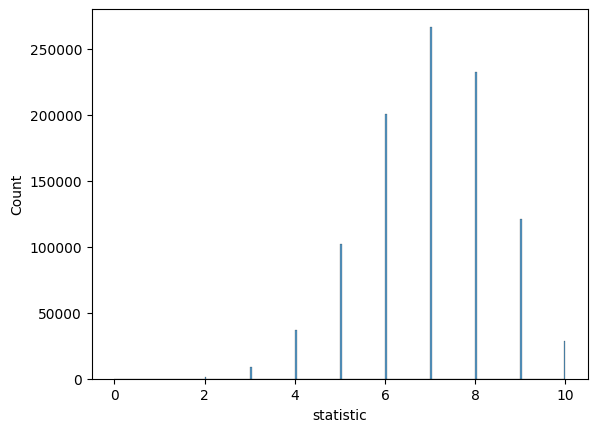

In [20]:
plot_discrete(df, plt.gca())

## The Binomial Distribution

The sampling distribution for the count of positive outcomes from n flips of a coin has its own name, the **Binomial Distribution**.

The binomial distribution takes two parameters, the number of flips, `n`, and the probability of heads on each flip, `p`.

Like some other simple distributions, there is a formula for the probability mass function, though we will use simulations rather than the function to build our intuitions about the probability of different outcomes.

$$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$$
Where:
- p is the probability of success on a single trial
- n is the number of trials
- k is the number of successes
- $P(X=k)$ is the probability of exactly k successes in n trials
- $\binom{n}{k}$ is the binomial coefficient, which can be calculated as $\frac{n!}{k!(n-k)!}$


We've actually already been simulating that distribution, so let's package it up into a python function.

In [21]:
def binomial(n, p, n_simulations=1000):
    return simulate_sampling_distribution(
        underlying_distribution_simulator=lambda sample_size: draw_bernoulli(
            p, sample_size
        ),
        sample_statistic=lambda df: df["Outcome"].sum(),
        n_simulations=n_simulations,
        sample_size=n,
    )

In [22]:
binomial(10, 0.5)

,statistic
0,4
1,1
2,4
3,2
4,5
...,...
995,7
996,3
997,6
998,3


Let's develop some intuitions about how the binomial distribution changes as we vary n and p

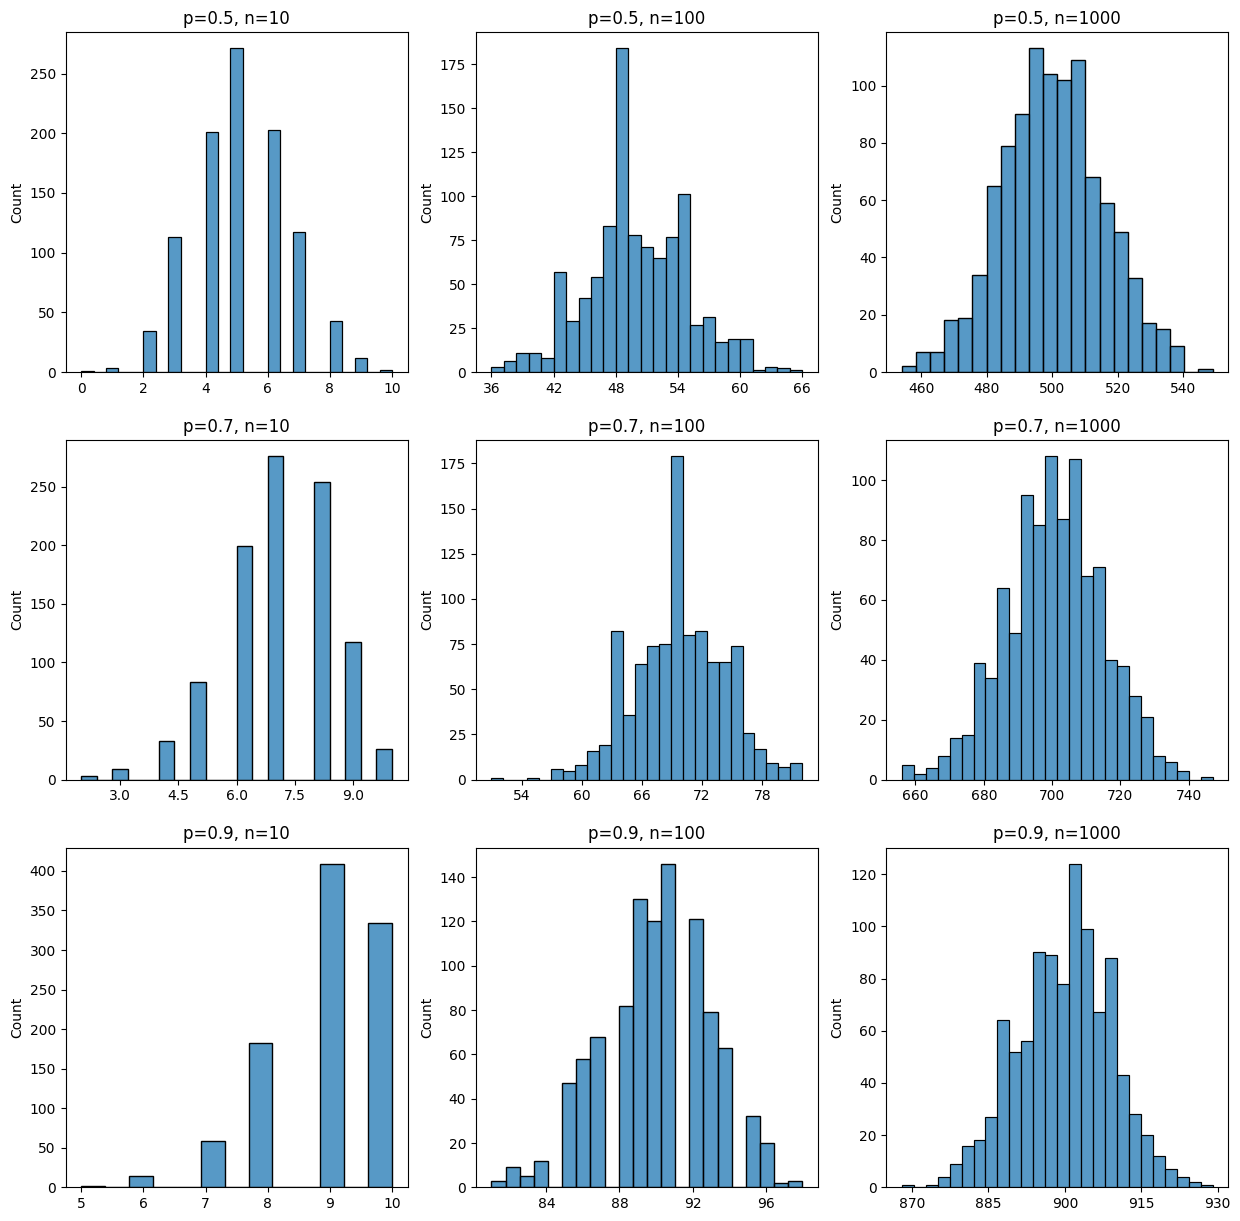

In [23]:
# set the same random seed for reproducibility
np.random.seed(42)

# make a 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
# try p in [0.5, .7, .9] and n in [10, 100, 1000]
for i, p in enumerate([0.5, 0.7, 0.9]):
    for j, n in enumerate([10, 100, 1000]):
        df = binomial(n, p)
        plot_discrete(df, axes[i, j], num_ticks=6)
        axes[i, j].set_title(f"p={p}, n={n}")
        axes[i,j].set_xlabel("")

There's actually a built-in object for the binomial distribution, in both numpy and scipy!

I (re)defined it in this notebook so you could understand it as an example of a sampling distribution. But in practice we would actually just use the built-in method.

In [24]:
# redefine bionomial function using np.random.Generator.binomial

def binomial(n, p, n_simulations=1000):
    return pd.DataFrame(
        {
            "statistic": rng.binomial(n, p, size=n_simulations),
        }
    )

In [25]:
binomial(10, 0.7)

,statistic
0,7
1,7
2,6
3,10
4,7
...,...
995,9
996,7
997,5
998,6


In [26]:
df = binomial(10, 0.7, n_simulations=1000000)
df["statistic"].value_counts().sort_index()

statistic
0          9
1        142
2       1519
3       9144
4      36661
5     102690
6     200154
7     266209
8     234135
9     121079
10     28258
Name: count, dtype: int64

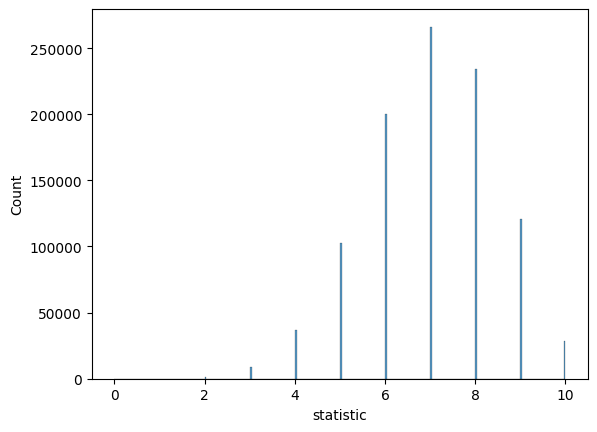

In [27]:
plot_discrete(df, plt.gca())